# Econ 771 - Problem Set 6
Coding Part

In [1]:
# Import necessary packages

from scipy.stats import norm
import numpy as np
import torch
import matplotlib.pyplot as plt
import math , gc

# Cleans gpu to use
for name, obj in list(globals().items()):
    if torch.is_tensor(obj) and obj.is_cuda:
        del obj

# Empty CUDA cache
torch.cuda.empty_cache()

In [2]:
# This is for the timing of the code run time, please do not modify
import time
start_time = time.time()

In [3]:
M=1000 #Monte carlo runs
B=200 #Bootstrap resamples
# Total loops 1 mln

#Move all computations to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Exercise I

<blockquote>

<b>

This exercise is a continuation of the Exercise I from the Problem Set 3. Consider the DGP with heteroskedastic regression errors as in part 2.

</b>

</blockquote>

<b>

1. Explore the distribution of the OLS estimator under heteroskedasticity using Eicker-White standard errors (follow steps (a)-(e)). Next, increase the sample to n = 100 observations and repeat everything. Conclude.

Reminder of PS3 part 2:

Now we introduce heteroskedasticity as follows
$$Y = \beta_1 + \beta_2 X_2 + \beta_3 X_3 + \tilde{\epsilon},$$

with coefficients set to $\beta_1 = 1$, $\beta_2 = 2$, $\beta_3 = 3$ and the data generated as $X_2 \sim N(0, 1)$, $X_3 \sim N(0, 1)$, $\epsilon \sim N(0, 1)$ with $X_2 \coprod X_3 \coprod \epsilon$, where $\tilde{\epsilon} = \epsilon(X_2 + X_3)$.

</b>

**(a) For each $m = 1, \dots, M$, compute the OLS estimator $\hat{\beta}_m = (\hat{\beta}_{1m}, \hat{\beta}_{2m}, \hat{\beta}_{3m})^T$.**

In [4]:
beta_true = torch.tensor([1.0, 2.0, 3.0], device=device)  # (β1, β2, β3)
n=20 # Use n as in PS3
#>--------------------------------------------------------

X = torch.randn(M, n, 3, device=device) #Generate M different X matrices. of sample size n
xpx=X[:, :, 1] + X[:, :, 2]  #Creating X2 X3 term
X[:, :, 0] = X[:, :, 0] * (xpx)  #Creating the new error term
Y= X@beta_true +1.0   #  Generating the Y's
errors=X[:, :, 0].clone() # clones not to affect the original during manipulations
X[:, :, 0] = 1.0  #Replace error column with the constant column to create the features matrix


#Compute the estimators
# Compute estimates
XtX = X.transpose(1, 2) @ X      # shape: ( M, 3, 3)
XtX_inv = torch.linalg.inv(XtX)  # shape: ( M, 3, 3)

beta_hat= XtX_inv @ X.transpose(1, 2)@Y.view(M, n, 1) # (M,k,1)

error_hat = Y.view(M, n, 1) - X@ beta_hat  #

num_sims, num_obs = 2, 3
print("Examples of estimates")
print(
    "\n\n".join(
        [f"--- Simulation {i+1} ---\n"
         + " | ".join([f"beta_{j+1}={b:.4f}" for j, b in enumerate(beta_hat[i,:,0].tolist())])
         + f"\nerror_hat (first {num_obs} obs): "
         + ", ".join([f"{e:.4f}" for e in error_hat[i,:num_obs,0].tolist()])
         for i in range(num_sims)]
    )
)


Examples of estimates
--- Simulation 1 ---
beta_1=1.0010 | beta_2=2.4752 | beta_3=3.6699
error_hat (first 3 obs): 0.1310, -1.6605, 0.3672

--- Simulation 2 ---
beta_1=0.8373 | beta_2=2.6487 | beta_3=3.3065
error_hat (first 3 obs): 0.9695, -0.4801, 0.1379


In [5]:
# Compute meat matrix: X' diag(u^2) X
u2 = error_hat.squeeze(-1)**2          # (M,n)

# Multiply each row of X by u^2
Xu = X * u2.unsqueeze(-1)              # (M,n,k)

# X' diag(u^2) X
meat = X.transpose(1,2) @ Xu           # (M,k,k)

# Eicker-White covariance
V_hat = XtX_inv @ meat @ XtX_inv       # (M,k,k)
# Se
se = torch.sqrt(torch.diagonal(V_hat, dim1=1, dim2=2))  # (M,k)
#
beta_hat_flat = beta_hat.squeeze(-1)   # (M,k)
t_stat_true = (beta_hat_flat - beta_true) / se   # (M,k)
empirical_size = (torch.abs(t_stat_true) > 1.96).float().mean(dim=0)

**(b) Plot three histograms of standardized estimators assuming that $\sigma^2$ is known. Plot the probability density function of $N(0, 1)$ at each histogram.**

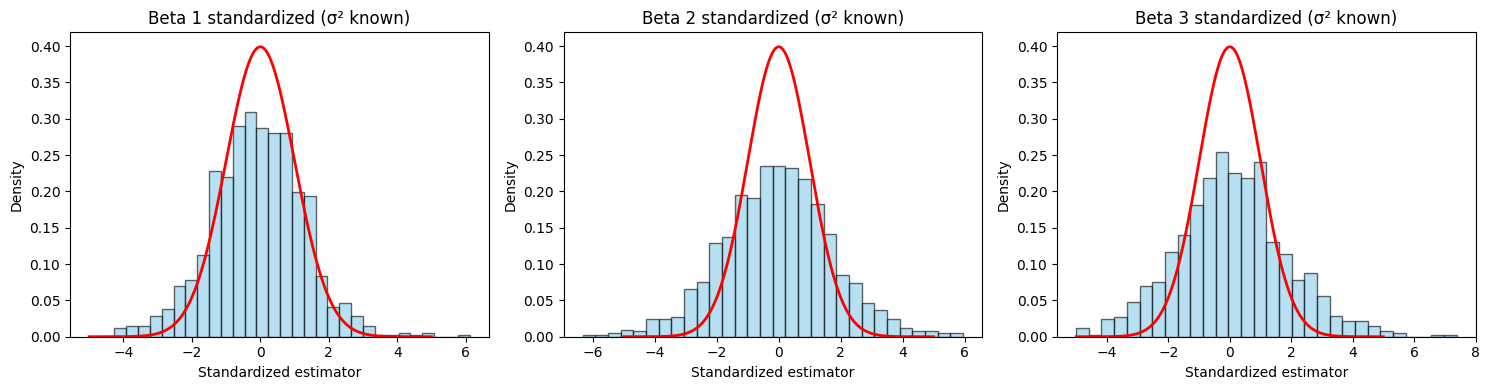

In [6]:


# Move tensors to CPU for plotting
beta_hat_cpu = beta_hat_flat.cpu().numpy()  # (M,k)
XtX_inv_cpu = XtX_inv.cpu().numpy()         # (M,k,k)
V_hat_cpu = V_hat.cpu().numpy()             # (M,k,k)
beta_true_cpu = beta_true.cpu().numpy()     # (k,)

M, k = beta_hat_cpu.shape

# ---------------------------
# (b) Standardize using known sigma^2 = 1 (assuming errors multiplied by 1)
# z_km = (beta_hat - beta_true) / sqrt(sigma^2 * (X'X)^{-1}_kk)
# Use mean of diagonal of XtX_inv for simplicity as approximation
sigma2_true = 1.0
std_known = np.sqrt(XtX_inv_cpu.diagonal(axis1=1, axis2=2) * sigma2_true)  # (M,k)
z_true = (beta_hat_cpu - beta_true_cpu) / std_known  # (M,k)

# Plot histograms with N(0,1) overlay
fig, axes = plt.subplots(1, k, figsize=(5*k,4))
x_vals = np.linspace(-5,5,500)
for j in range(k):
    axes[j].hist(z_true[:,j], bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='k')
    axes[j].plot(x_vals, norm.pdf(x_vals, 0, 1), 'r', lw=2)
    axes[j].set_title(f'Beta {j+1} standardized (σ² known)')
    axes[j].set_xlabel('Standardized estimator')
    axes[j].set_ylabel('Density')
plt.tight_layout()
plt.show()

# ---------------------------


**(c) Replace $\sigma^2$ by the Eicker-White standard error estimator $\hat{\sigma}^2$ and plot histograms of $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\hat{\sigma}^2 (X^T X)^{-1}}}$ with the probability function of $N(0, 1)$. What is the distribution of the standardized estimators now?**

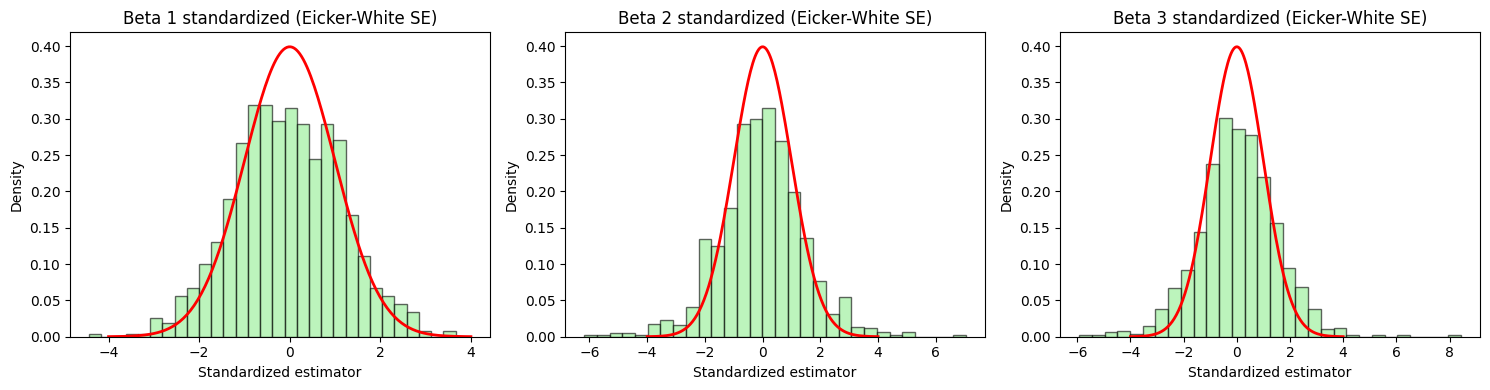

In [7]:

# Move to CPU & convert to NumPy
z_ew_np = t_stat_true.cpu().numpy()

# x-axis for normal curve
x_vals = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, k, figsize=(5*k,4))

for j in range(k):
    axes[j].hist(z_ew_np[:, j], bins=30, density=True, alpha=0.6, color='lightgreen', edgecolor='k')
    axes[j].plot(x_vals, norm.pdf(x_vals, 0, 1), 'r', lw=2)
    axes[j].set_title(f'Beta {j+1} standardized (Eicker-White SE)')
    axes[j].set_xlabel('Standardized estimator')
    axes[j].set_ylabel('Density')

plt.tight_layout()
plt.show()

**(d) Fix significance level at 5%. Compute the empirical size of the t-test – the fraction of times you reject the null-hypothesis when it is actually correct.**

In [8]:


print("The fraction of times you reject the null-hypothesis when it is actually correct:")
print(empirical_size)

The fraction of times you reject the null-hypothesis when it is actually correct:
tensor([0.1010, 0.1490, 0.1640], device='cuda:0')


**(e) Compute the empirical power of the t-test for the significance test ($H_0 : \beta_k = 0$) – the fraction of times you reject the null-hypothesis.**

In [9]:
t_stat = (beta_hat_flat - torch.tensor([0,0,0], device = "cuda")) / se   # (M,k)
empirical_power = (torch.abs(t_stat) > 1.96).float().mean(dim=0)

print("empirical power of the t-test for the significance test ($H_0 : \beta_k = 0$) – the fraction of times you reject the null-hypothesis.:")
print(empirical_power)

empirical power of the t-test for the significance test ($H_0 : eta_k = 0$) – the fraction of times you reject the null-hypothesis.:
tensor([0.8980, 0.9890, 1.0000], device='cuda:0')


# REPEAT N=100


Examples of estimates
--- Simulation 1 ---
beta_1=0.8339 | beta_2=2.0127 | beta_3=3.0785
error_hat (first 3 obs): -1.8349, -1.1688, 0.4119

--- Simulation 2 ---
beta_1=1.1358 | beta_2=2.2937 | beta_3=3.3779
error_hat (first 3 obs): -2.6755, -0.0863, 2.0670
/n >--------------------------------------------------------------


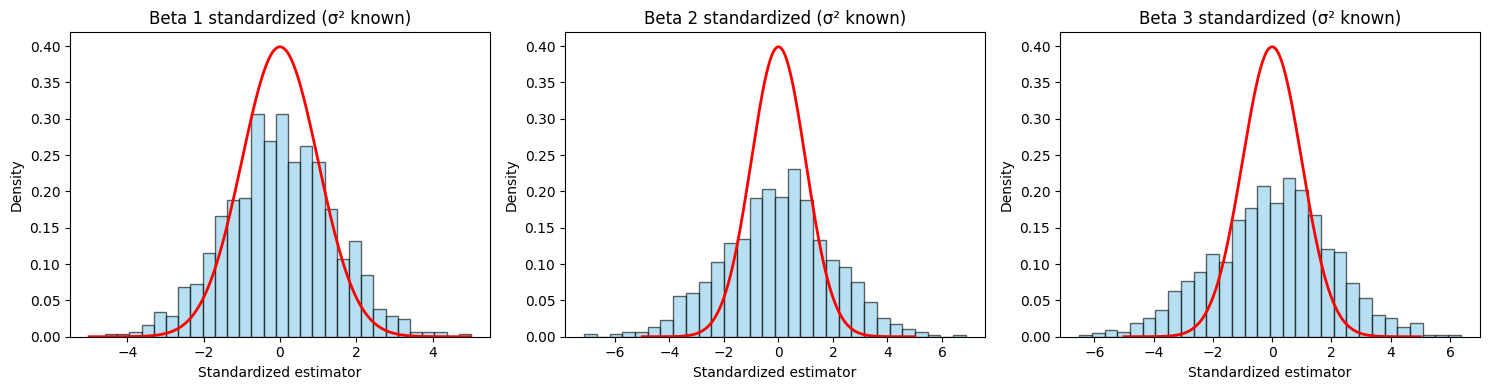

/n >--------------------------------------------------------------


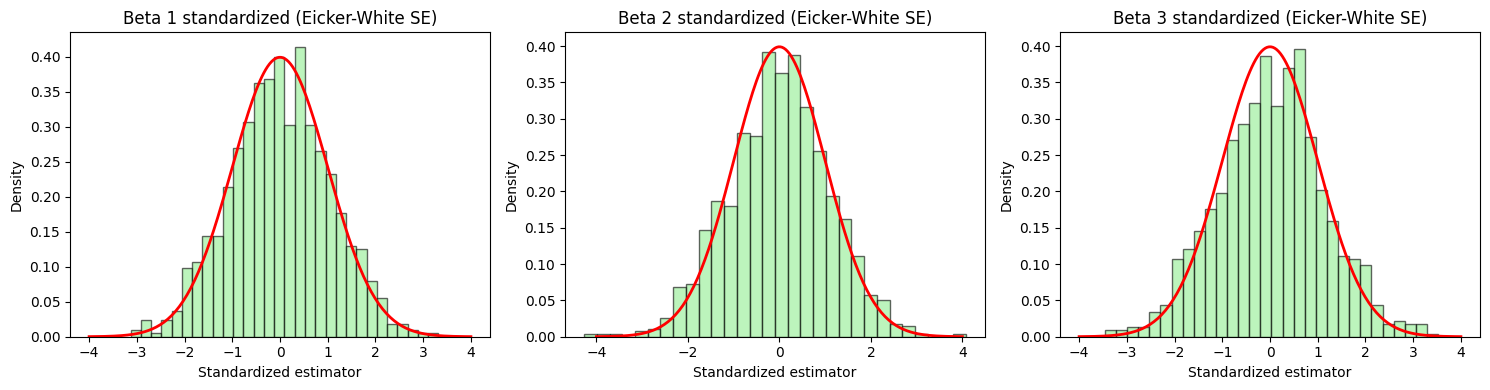

/n >--------------------------------------------------------------
The fraction of times you reject the null-hypothesis when it is actually correct:
tensor([0.0570, 0.0720, 0.0820], device='cuda:0')
/n >--------------------------------------------------------------
empirical power of the t-test for the significance test ($H_0 : eta_k = 0$) – the fraction of times you reject the null-hypothesis.:
tensor([1., 1., 1.], device='cuda:0')


In [10]:
beta_true = torch.tensor([1.0, 2.0, 3.0], device=device)  # (β1, β2, β3)
n=100 # Use n as in PS3
#>--------------------------------------------------------

X = torch.randn(M, n, 3, device=device) #Generate M different X matrices. of sample size n
xpx=X[:, :, 1] + X[:, :, 2]  #Creating X2 X3 term
X[:, :, 0] = X[:, :, 0] * (xpx)  #Creating the new error term
Y= X@beta_true +1.0   #  Generating the Y's
errors=X[:, :, 0].clone() # clones not to affect the original during manipulations
X[:, :, 0] = 1.0  #Replace error column with the constant column to create the features matrix


#Compute the estimators
# Compute estimates
XtX = X.transpose(1, 2) @ X      # shape: ( M, 3, 3)
XtX_inv = torch.linalg.inv(XtX)  # shape: ( M, 3, 3)

beta_hat= XtX_inv @ X.transpose(1, 2)@Y.view(M, n, 1) # (M,k,1)

error_hat = Y.view(M, n, 1) - X@ beta_hat  #

num_sims, num_obs = 2, 3
print("Examples of estimates")
print(
    "\n\n".join(
        [f"--- Simulation {i+1} ---\n"
         + " | ".join([f"beta_{j+1}={b:.4f}" for j, b in enumerate(beta_hat[i,:,0].tolist())])
         + f"\nerror_hat (first {num_obs} obs): "
         + ", ".join([f"{e:.4f}" for e in error_hat[i,:num_obs,0].tolist()])
         for i in range(num_sims)]
    )
)
# Compute meat matrix: X' diag(u^2) X
u2 = error_hat.squeeze(-1)**2          # (M,n)

# Multiply each row of X by u^2
Xu = X * u2.unsqueeze(-1)              # (M,n,k)

# X' diag(u^2) X
meat = X.transpose(1,2) @ Xu           # (M,k,k)

# Eicker-White covariance
V_hat = XtX_inv @ meat @ XtX_inv       # (M,k,k)
# Se
se = torch.sqrt(torch.diagonal(V_hat, dim1=1, dim2=2))  # (M,k)
#
beta_hat_flat = beta_hat.squeeze(-1)   # (M,k)
t_stat_true = (beta_hat_flat - beta_true) / se   # (M,k)
empirical_size = (torch.abs(t_stat_true) > 1.96).float().mean(dim=0)




# Move tensors to CPU for plotting
beta_hat_cpu = beta_hat_flat.cpu().numpy()  # (M,k)
XtX_inv_cpu = XtX_inv.cpu().numpy()         # (M,k,k)
V_hat_cpu = V_hat.cpu().numpy()             # (M,k,k)
beta_true_cpu = beta_true.cpu().numpy()     # (k,)

M, k = beta_hat_cpu.shape

# ---------------------------
# (b) Standardize using known sigma^2 = 1 (assuming errors multiplied by 1)
# z_km = (beta_hat - beta_true) / sqrt(sigma^2 * (X'X)^{-1}_kk)
# Use mean of diagonal of XtX_inv for simplicity as approximation
sigma2_true = 1.0
std_known = np.sqrt(XtX_inv_cpu.diagonal(axis1=1, axis2=2) * sigma2_true)  # (M,k)
z_true = (beta_hat_cpu - beta_true_cpu) / std_known  # (M,k)
print("/n >--------------------------------------------------------------")

# Plot histograms with N(0,1) overlay
fig, axes = plt.subplots(1, k, figsize=(5*k,4))
x_vals = np.linspace(-5,5,500)
for j in range(k):
    axes[j].hist(z_true[:,j], bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='k')
    axes[j].plot(x_vals, norm.pdf(x_vals, 0, 1), 'r', lw=2)
    axes[j].set_title(f'Beta {j+1} standardized (σ² known)')
    axes[j].set_xlabel('Standardized estimator')
    axes[j].set_ylabel('Density')
plt.tight_layout()
plt.show()
print("/n >--------------------------------------------------------------")

# ---------------------------

# Move to CPU & convert to NumPy
z_ew_np = t_stat_true.cpu().numpy()

# x-axis for normal curve
x_vals = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, k, figsize=(5*k,4))

for j in range(k):
    axes[j].hist(z_ew_np[:, j], bins=30, density=True, alpha=0.6, color='lightgreen', edgecolor='k')
    axes[j].plot(x_vals, norm.pdf(x_vals, 0, 1), 'r', lw=2)
    axes[j].set_title(f'Beta {j+1} standardized (Eicker-White SE)')
    axes[j].set_xlabel('Standardized estimator')
    axes[j].set_ylabel('Density')

plt.tight_layout()
plt.show()


print("/n >--------------------------------------------------------------")

print("The fraction of times you reject the null-hypothesis when it is actually correct:")
print(empirical_size)

t_stat = (beta_hat_flat - torch.tensor([0,0,0], device = "cuda")) / se   # (M,k)
empirical_power = (torch.abs(t_stat) > 1.96).float().mean(dim=0)
print("/n >--------------------------------------------------------------")

print("empirical power of the t-test for the significance test ($H_0 : \beta_k = 0$) – the fraction of times you reject the null-hypothesis.:")
print(empirical_power)



```
# This is formatted as code
```

**(f) Conclude.**

## Conclusion

Eicker-White robust standard errors perform well in controlling Type I error under heteroskedasticity. With a larger sample (n=100), the t-tests achieve near-perfect power and accurate inference, while in small samples (n=20), power is lower and estimates are more variable. Overall, robust SEs are reliable in larger samples for more precise and powerful statistical inference.

<b>

2. Now we fix the sample size at n = 30 observations. Explore empirical size and power properties (You don’t need to plot histograms for this part.) of the t-test using the following wild bootstrap procedure (you have to do the bootstrap for each Monte Carlo replication. You can try parallel computing.):

<ol>

<li> For each MC replication, $m = 1, \dots, M$, simulate the data. Estimate the linear regression coefficient $\hat{\beta}$ and compute residuals $\hat{u}$; </li>

<li> Create $B$ bootstrap samples using the wild bootstrap
$$Y_i^* = X_i^T \hat{\beta} + \eta_i \hat{u}_i, \ \ \ \ i = 1, \dots, n,$$ </li>

where $\eta_i$ are i.i.d. draws from the two-point distribution introduced in class (Please check my pdf notes in order to make sure that the you draw from the correct two-point distribution.). </li>

<li> For each bootstrap sample, estimate the linear regression coefficients $(\hat{\beta})_{b=1}^B$ and Eicker-White standard errors $\{se(\hat{\beta}_{k,b}^*) = \sqrt{\hat{V}_{k,b}^*/n}: k = 1, 2, 3, b = 1, \dots, B\}$, where $\hat{V}_{k,b}^*$ is the kth diagonal element of the Eicker-White covariance matrix estimator. Compute absolute values of t-statistics
$$T_{n,k}^b = |\frac{\hat{\beta}_{k,b}^* - \hat{\beta}}{se(\hat{\beta}_{k,b}^*)}|, \ \ \ \ b = 1, \dots, B, \ \ k = 1, 2, 3.$$ </li>

<li> Estimate 0.975th quantile of $(T_{n,k}^b)_{b=1}^B$ for k = 1, 2, 3, denoted $q_{0.975,k}^*$. </li>

<li> Reject if $T_{n,k} = |\frac{\hat{\beta}_k - \beta_{k,0}}{\sqrt{\hat{V}_k/n}}| > q_{0.975,k}^*$ (It is recommended to impose symmetry for quantiles as long as the asymptotic distribution is symmetric, e.g., N(0, 1).). </li>

</ol>

</b>

In [11]:
n=30
  # (β1, β2, β3)
# Take the first 30 rows along the n dimension
X_n = X[:, :n, :]   # shape: (M, 30, 3)
Y_n = Y[:, :n].view(-1,n,1)   # shape: (M, 30, 1)



In [12]:
# 1) Estimate beta_hat and u_hat
XtX = X_n.transpose(1, 2) @ X_n      # shape: ( M, k, k)
XtX_inv = torch.linalg.inv(XtX)  # shape: ( M, k, k)
beta_hat= XtX_inv @ X_n.transpose(1, 2)@Y_n# ( M, k, 1)
Y_fitted = X_n @ beta_hat
u_hat = Y_n - Y_fitted #


In [13]:
# 2) Create B bootstrap samples
btp = torch.randint(0, 2, (M, B, n, 1), device='cuda').mul_(2).sub_(1)

u_star = u_hat.unsqueeze(1) * btp # (M, B, n, 1)


Y_star = Y_fitted.unsqueeze(1) + u_star  # (M, B, n, 1)




In [14]:
# 3) For each bootstrap sample compute estimates, standard error and T stats
XtY_star = X_n.transpose(1,2).unsqueeze(1) @ Y_star
# (M, B, k, 1)

beta_star = XtX_inv.unsqueeze(1) @ XtY_star
# (M, B, k, 1)

u_star_hat = Y_star - X_n.unsqueeze(1) @ beta_star

# square residuals
u2 = u_star_hat.squeeze(-1)**2                    # (M, B, n)

# form X' diag(u^2) X efficiently
middle = (
    X_n.unsqueeze(1).transpose(-1, -2)
    @ (X_n.unsqueeze(1) * u2.unsqueeze(-1))
)                                                 # (M, B, k, k)

# sandwich
XtX_inv_exp = XtX_inv.unsqueeze(1)                # (M, 1, k, k)
V_hat = XtX_inv_exp @ middle @ XtX_inv_exp       # (M, B, k, k)

se_star = (
    V_hat.diagonal(dim1=-2, dim2=-1) / n
).sqrt()

# reshape original beta_hat
beta_hat_exp = beta_hat.unsqueeze(1)              # (M, 1, k, 1)

# difference
diff = (beta_star - beta_hat_exp).squeeze(-1)     # (M, B, k)

# t statistics
T = (diff / se_star).abs()                        # (M, B, k)


In [15]:
# Assume se_hat is original robust SE, shape (M, k)
# If you only have se_star from bootstrap, take the mean across B as proxy
se_hat = se_star.mean(dim=1)  # shape (M, k)

# Original t-statistics for null beta_k = 0
T_orig = ((beta_hat.squeeze(-1)-beta_true) / se_hat).abs()  # shape (M, k)

# Critical value from bootstrap
q_crit = T.quantile(1 - 0.025, dim=1)  # shape (M, k)

# Reject if T_orig > q_crit
reject = T_orig > q_crit  # shape (M, k), boolean

# Empirical size: fraction of rejections across M
empirical_size = reject.float().mean(dim=0)  # shape (k,)

print("Empirical size for each coefficient:", empirical_size)

Empirical size for each coefficient: tensor([0.0440, 0.0570, 0.0530], device='cuda:0')


**3. Compare your results for the finite-sample approach (PS 3), the asymptotic approach (Eicker-White), and the bootstrap.**

## Conclusion

Comparing the two approaches, we find:

- **Asymptotic robust (Eicker-White) SEs:** Control Type I error reasonably well in moderate to large samples, but can be slightly inflated in small samples.   
- **Wild bootstrap:** Provides empirical size closest to the nominal level, improving inference accuracy in smaller samples.  

**Overall:** The wild bootstrap offers the most reliable finite-sample inference, while robust SEs perform well as sample size increases.

In [16]:
# This is for the timing of the code run time, please do not modify
end_time = time.time()

print(f"Total runtime: {end_time - start_time} seconds")

Total runtime: 6.551686763763428 seconds
